In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import numpy as np

# add parent dir so importing top level files works in notebook subdir
parent_dir = str(Path().resolve().parent)
sys.path.insert(0, parent_dir)

import qwen_vl
from autoencoder.model_qwen import QwenAutoencoder

## If you need to decode any latent space features do it before loading the qwen model otherwise we run out of GPU ram

In [2]:
ae = QwenAutoencoder(
    input_dim=3584,
    latent_dim=3,
).to("cuda")
ae.load_state_dict(torch.load("../data/cholecseg8k/preprocessed_ssg/video43/video43_00147/autoencoder/best_ckpt.pth", map_location="cuda"))
ae.eval()

QwenAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3584, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=1024, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=32, bias=True)
    (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): GELU(approximate='none')
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=1024, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_featur

In [3]:
raw_lfs = np.load("../data/cholecseg8k/preprocessed_ssg/video43/video43_00147/qwen_patch_features/frame_000000_f.npy")
raw_lfs = torch.tensor(raw_lfs, dtype=torch.float32).to("cuda")
with torch.no_grad():
    ae_lfs = ae.decode(ae.encode(raw_lfs))

In [3]:
# grab a random rendered frame TODO is this novel view or training view?
rendered = np.load("../output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_qwenF3/video_lang/ours_10000/renders_npy/00328.npy")
rendered = torch.tensor(rendered, dtype=torch.float32).to("cuda")
rendered_norms = rendered.norm(dim=-1)
print(rendered.shape, rendered_norms.min(), rendered_norms.max())

torch.Size([952, 532, 3]) tensor(0.0236, device='cuda:0') tensor(0.9999, device='cuda:0')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.5716772..2.3546271].


torch.Size([3])


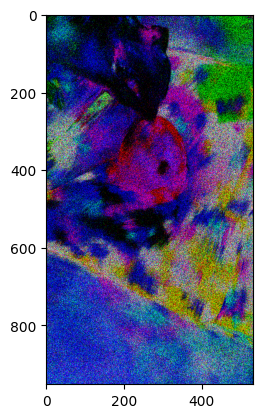

In [4]:
# add some noise while still in latent space
# maybe the autoencoder's latent space is not dense?
noise_level = rendered.std(dim=(0,1))
print(noise_level.shape)
rendered_noisy = rendered + torch.randn_like(rendered) * noise_level
plt.imshow(rendered_noisy.detach().cpu().numpy())


In [5]:
rendered_patch = rendered[::28, ::28, :]
rendered_noisy_patch = rendered_noisy[::28, ::28, :]
with torch.no_grad():
    rendered_decoded = ae.decode(rendered_patch).detach()
    rendered_noisy_decoded = ae.decode(rendered_noisy_patch).detach()
rendered_decoded_flat = rendered_decoded.reshape(-1, rendered_decoded.shape[-1])
rendered_noisy_decoded_flat = rendered_noisy_decoded.reshape(-1, rendered_noisy_decoded.shape[-1])
rendered_decoded_flat_randperm = rendered_decoded_flat[torch.randperm(rendered_decoded_flat.shape[0])]

In [6]:
noise_level = rendered_decoded_flat.std(dim=0)
rendered_decoded_flat_noised = rendered_decoded_flat + torch.randn_like(rendered_decoded_flat) * noise_level

In [4]:
# RUN THIS!
del ae

## Cluster wise data

In [14]:
data_path = Path('../output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_base/graph/cluster_qwen_features_full_33.npy')
feats = torch.tensor(np.load(data_path), dtype=torch.float32).to("cuda")
feats_norms = feats.norm(dim=-1)
print(feats.shape, feats_norms.min(), feats_norms.max())

torch.Size([100, 3584]) tensor(17.9722, device='cuda:0') tensor(83.9186, device='cuda:0')


## Load model and ask

In [5]:
model, processor = qwen_vl.get_patched_qwen()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [6]:
print("raw:", qwen_vl.ask_qwen_about_image_features(
    raw_lfs,
    "What do you see in this image?",
    model,
    processor,
    system_prompt="You are a helpful assistant.",
))
print("ae:", qwen_vl.ask_qwen_about_image_features(
    ae_lfs,
    "What do you see in this image?",
    model,
    processor,
    system_prompt="You are a helpful assistant.",
))

raw: This image appears to be a medical photograph, likely taken during a surgical procedure or endoscopic examination. The tissue shown is highly vascular and has a reddish-pink hue, which could indicate the interior of an organ such as the stomach, intestine, or another part of the gastrointestinal tract. The presence of fluid and the texture suggest it might be from a laparoscopic or endoscopic view.

However, without more context or a clinical report, it's not possible to definitively identify the specific organ or condition being observed. If you have any additional information about the setting or purpose of the image, please provide that so I can offer a
ae: This image appears to be a medical photograph, likely taken during a surgical procedure or endoscopic examination. The tissue shown is reddish-pink and has a smooth surface with visible blood vessels, which suggests it could be part of the gastrointestinal tract, such as the stomach or small intestine. The presence of fluid 

In [ ]:
print("Plain:", qwen_vl.ask_qwen_about_image_features(
    rendered_decoded_flat,
    "What do you see in this image?",
    model,
    processor,
    system_prompt="You are a helpful assistant.",
))
print("Scrambled:", qwen_vl.ask_qwen_about_image_features(
    rendered_decoded_flat_randperm,
    "What do you see in this image?",
    model,
    processor,
    system_prompt="You are a helpful assistant.",
))
print("Latent space noised:", qwen_vl.ask_qwen_about_image_features(
    rendered_noisy_decoded_flat,
    "What do you see in this image?",
    model,
    processor,
    system_prompt="You are a helpful assistant.",
))
print("Full dim noised:", qwen_vl.ask_qwen_about_image_features(
    rendered_decoded_flat_noised,
    "What do you see in this image?",
    model,
    processor,
    system_prompt="You are a helpful assistant.",
))

Plain The image shows a person's hands holding an orange plastic egg-shaped object that appears to be a container or mold. The container is open, revealing a white interior, and the person seems to be either placing something inside or removing it. The object is placed on a wooden cutting board, which is on a surface with a white cloth underneath. In the background, there is a gray object that looks like a piece of fabric or a bag.
Scrambled The image shows a person's hands holding an orange egg-shaped object that appears to be a kitchen tool, possibly an egg timer or a device for cooking eggs. The object is being opened, revealing the inside of the egg. The background includes a wooden cutting board and a white cloth.
Latent space noised The image shows a person's hands holding an orange egg-shaped container with a lid that has a small opening. Inside the container, there is a yellow object that resembles a chick or a similar figure. The container and its contents appear to be placed 

In [15]:
print("Cluster:", qwen_vl.ask_qwen_about_image_features(
    feats,
    "What do you see in this image?",
    model,
    processor,
    system_prompt="You are a helpful assistant.",
))

Cluster: The image shows a person's hand holding an orange egg-shaped object, which appears to be a decorative or functional item, possibly a toy or a container. The background is a wooden surface, likely a cutting board or table.
